# Minería de Datos — Diagnóstico y Modelos Predictivos de una Planta Solar Fotovoltaica
## Dataset: `2107_electrical_data.csv` — 24 inversores, mediciones cada 5 minutos (2017–2023)

**Autor:** _(completar)_
**Curso:** Minería de Datos

---
### 1. Comprensión del problema

El dataset registra, cada 5 minutos y durante ~6 años (nov-2017 a nov-2023), las señales eléctricas de los **24 inversores** de una planta solar fotovoltaica: corriente y voltaje del lado DC (paneles) y corriente, voltaje y potencia del lado AC (salida hacia la red), para un total de 632,952 filas y 119 variables numéricas + 1 marca de tiempo.

**Problema de negocio.** Una planta solar necesita (a) entender el comportamiento normal de generación para planear el despacho de energía, (b) detectar inversores con desempeño anómalo o degradado (mantenimiento predictivo) y (c) pronosticar la producción futura para la toma de decisiones comerciales/operativas.

**Preguntas guía del análisis:**
1. ¿Cómo se comporta la potencia generada a lo largo del día, el mes y el año, y qué tan completos/consistentes son los datos de cada inversor?
2. ¿Es posible predecir la potencia AC total de la planta a partir de las señales eléctricas de entrada (DC) de los inversores? (**aprendizaje supervisado**)
3. ¿Existen grupos de inversores con perfiles de desempeño distintos, o inversores/periodos anómalos que sugieran fallas o degradación? (**aprendizaje no supervisado / diagnóstico**)
4. ¿Se puede anticipar la producción de energía de la planta en las próximas semanas a partir de su historial? (**forecasting**)

**Variable objetivo principal:** `total_ac_power` (suma de la potencia AC de los 24 inversores), usada tanto para el modelo supervisado como para el forecasting.

---
## 2. Imports y carga del dataset

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

CSV_PATH = '2107_electrical_data.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['measured_on'])
print(f'Shape original: {df.shape}')
df.head(3)

Shape original: (632952, 120)


,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 3. Exploración de datos (EDA)

### 3.1 Información general

In [2]:
print('=== TIPOS DE DATO ===')
print(df.dtypes.value_counts())
print()
print('=== ESTADÍSTICAS BÁSICAS (primeras 5 columnas) ===')
df.describe().iloc[:, :5]

=== TIPOS DE DATO ===
float64           119
datetime64[us]      1
Name: count, dtype: int64

=== ESTADÍSTICAS BÁSICAS (primeras 5 columnas) ===


,measured_on,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582
count,632952,632586.000000,632586.000000,632586.000000,632586.000000
mean,2020-11-04 00:06:34.443180,9.856498,319.205209,7.454513,136.362110
min,2017-11-01 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,2019-05-04 12:28:45,0.000000,0.000000,0.000000,0.000000
50%,2020-11-03 23:57:30,0.000000,0.000000,0.000000,0.000000
75%,2022-05-07 12:26:15,16.029000,675.261000,12.696000,286.213000
max,2023-11-07 23:55:00,52.348000,909.840000,36.363000,310.677000
std,NaN,15.343311,337.317409,11.367359,143.161743


### 3.2 Valores nulos

Los nulos no son errores de captura: corresponden a **inversores fuera de línea** (mantenimiento, falla de comunicación) durante ciertos intervalos. Se cuantifican por inversor para dimensionar el problema.

In [3]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(3)
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('nulos', ascending=False)
print(f'Columnas con nulos: {len(resumen_nulos)} de {df.shape[1]-1}')
print(f'Total de celdas nulas: {nulos.sum():,} ({nulos.sum()/df.size*100:.3f}% del total)')
resumen_nulos.head(15)

Columnas con nulos: 114 de 119
Total de celdas nulas: 183,372 (0.241% del total)


,nulos,%
inv_05_ac_current_inv_149601,1728,0.273
inv_05_ac_voltage_inv_149602,1728,0.273
inv_04_ac_voltage_inv_149597,1728,0.273
inv_04_ac_current_inv_149596,1728,0.273
inv_05_dc_current_inv_149599,1728,0.273
inv_04_ac_power_inv_149598,1728,0.273
inv_04_dc_voltage_inv_149595,1728,0.273
inv_04_dc_current_inv_149594,1728,0.273
inv_07_ac_voltage_inv_149612,1728,0.273
inv_07_ac_current_inv_149611,1728,0.273


### 3.3 Duplicados y calidad de nombres de columnas

Se revisan filas duplicadas y se detecta un **error tipográfico** en el nombre de una columna (`iinv` en vez de `inv`), típico de datasets capturados/exportados manualmente — se corrige en la etapa de preparación.

In [4]:
print('Filas duplicadas:', df.duplicated().sum())

# Columna con typo detectada por inspección de nombres
cols_atipicas = [c for c in df.columns if '_iinv_' in c]
print('Columnas con nombre atípico (typo):', cols_atipicas)

# inv_05 no tiene columna de dc_voltage (asimetría estructural entre inversores)
inv05_cols = [c for c in df.columns if c.startswith('inv_05_')]
print('Columnas de inv_05:', inv05_cols)

Filas duplicadas: 0
Columnas con nombre atípico (typo): ['inv_15_ac_power_iinv_149653']
Columnas de inv_05: ['inv_05_dc_current_inv_149599', 'inv_05_ac_current_inv_149601', 'inv_05_ac_voltage_inv_149602', 'inv_05_ac_power_inv_149603']


### 3.4 Rango temporal y frecuencia de muestreo

In [5]:
print(f'Fecha inicio  : {df["measured_on"].min()}')
print(f'Fecha fin     : {df["measured_on"].max()}')
duracion = df["measured_on"].max() - df["measured_on"].min()
print(f'Duración      : {duracion.days} días (~{duracion.days/365.25:.1f} años)')
print(f'Total filas   : {len(df):,}')
print(f'Frecuencia moda: {df["measured_on"].diff().mode()[0]}')

# Huecos temporales (gaps mayores a la frecuencia esperada de 5 min)
gaps = df['measured_on'].diff()
huecos = gaps[gaps > pd.Timedelta(minutes=5)]
print(f'Huecos temporales (>5 min): {len(huecos)}, el mayor de {huecos.max() if len(huecos) else "N/A"}')

Fecha inicio  : 2017-11-01 00:00:00
Fecha fin     : 2023-11-07 23:55:00
Duración      : 2197 días (~6.0 años)
Total filas   : 632,952
Frecuencia moda: 0 days 00:05:00
Huecos temporales (>5 min): 6, el mayor de 0 days 01:05:00


### 3.5 Variable objetivo: potencia AC total de la planta

In [6]:
power_cols = [c for c in df.columns if 'ac_power' in c]
df['total_ac_power'] = df[power_cols].sum(axis=1, min_count=1)

print(f'Inversores con columna de potencia AC: {len(power_cols)}')
print(df['total_ac_power'].describe())

zeros_pct = (df[power_cols] == 0).mean() * 100
print('\n% de lecturas en cero por inversor (rango nocturno + posibles fallas):')
print(zeros_pct.sort_values(ascending=False).round(2))

Inversores con columna de potencia AC: 24
count    632952.000000
mean        156.322502
std         230.963511
min           0.000000
25%           0.000000
50%           0.000000
75%         291.599750
max         721.609000
Name: total_ac_power, dtype: float64

% de lecturas en cero por inversor (rango nocturno + posibles fallas):
inv_07_ac_power_inv_149613     59.19
inv_06_ac_power_inv_149608     58.10
inv_04_ac_power_inv_149598     57.39
inv_02_ac_power_inv_149588     57.22
inv_17_ac_power_inv_149663     55.91
inv_24_ac_power_inv_149698     55.81
inv_23_ac_power_inv_149693     55.07
inv_01_ac_power_inv_149583     55.07
inv_08_ac_power_inv_149618     55.06
inv_05_ac_power_inv_149603     55.05
inv_21_ac_power_inv_149683     54.95
inv_14_ac_power_inv_149648     54.44
inv_03_ac_power_inv_149593     54.41
inv_16_ac_power_inv_149658     54.33
inv_10_ac_power_inv_149628     54.30
inv_15_ac_power_iinv_149653    53.63
inv_19_ac_power_inv_149673     53.60
inv_18_ac_power_inv_149668     53.50

### 3.6 Distribuciones de las variables clave

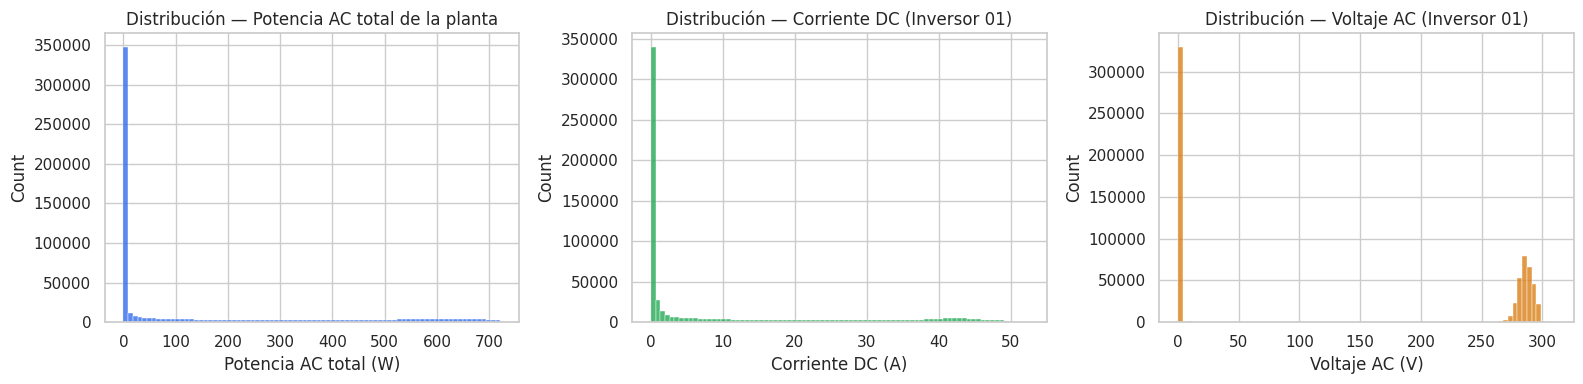

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['total_ac_power'].dropna(), bins=80, ax=axes[0], color='#2563eb')
axes[0].set_title('Distribución — Potencia AC total de la planta')
axes[0].set_xlabel('Potencia AC total (W)')

sns.histplot(df['inv_01_dc_current_inv_149579'].dropna(), bins=80, ax=axes[1], color='#16a34a')
axes[1].set_title('Distribución — Corriente DC (Inversor 01)')
axes[1].set_xlabel('Corriente DC (A)')

sns.histplot(df['inv_01_ac_voltage_inv_149582'].dropna(), bins=80, ax=axes[2], color='#d97706')
axes[2].set_title('Distribución — Voltaje AC (Inversor 01)')
axes[2].set_xlabel('Voltaje AC (V)')

plt.tight_layout()
plt.savefig('fig_distribuciones.png', dpi=120)
plt.show()

### 3.7 Comportamiento por dispositivo — Boxplot comparativo entre inversores

Permite detectar inversores con comportamiento atípico (menor producción, mayor variabilidad) respecto al resto de la flota.

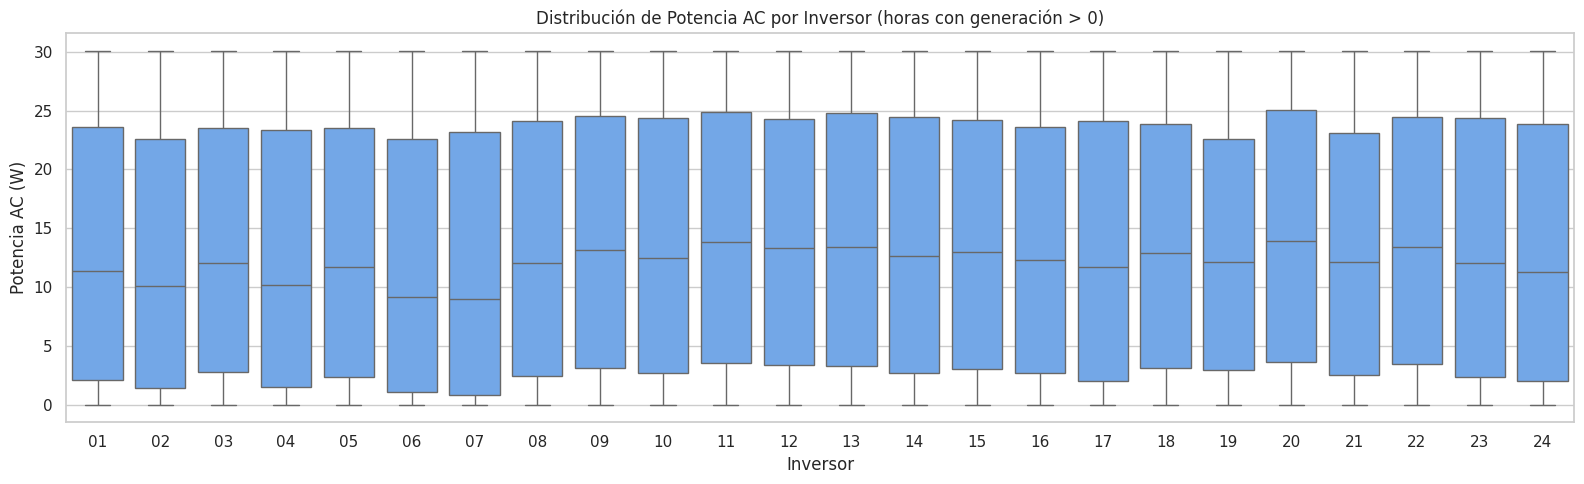

Mediana de potencia AC por inversor:
inversor
07     8.9980
06     9.1750
02    10.0690
04    10.2090
24    11.2830
01    11.3450
05    11.6550
17    11.6760
23    12.0250
08    12.0690
03    12.0800
19    12.1440
21    12.1490
16    12.3000
10    12.5000
14    12.5990
18    12.9100
15    12.9330
09    13.1300
12    13.2765
22    13.3610
13    13.4010
11    13.7875
20    13.8780
Name: potencia_ac, dtype: float64


In [8]:
ac_power_by_inv = df[power_cols].copy()
ac_power_by_inv.columns = [c.split('_')[1] for c in power_cols]  # solo el número de inversor
# Solo horas con generación > 0 para comparar de forma justa
mask_dia = df['total_ac_power'] > 0
melted = ac_power_by_inv[mask_dia].melt(var_name='inversor', value_name='potencia_ac')

plt.figure(figsize=(16, 5))
sns.boxplot(data=melted, x='inversor', y='potencia_ac', showfliers=False, color='#60a5fa')
plt.title('Distribución de Potencia AC por Inversor (horas con generación > 0)')
plt.ylabel('Potencia AC (W)')
plt.xlabel('Inversor')
plt.tight_layout()
plt.savefig('fig_boxplot_inversores.png', dpi=120)
plt.show()

print('Mediana de potencia AC por inversor:')
print(melted.groupby('inversor')['potencia_ac'].median().sort_values())

### 3.8 Patrón diurno y estacional de generación

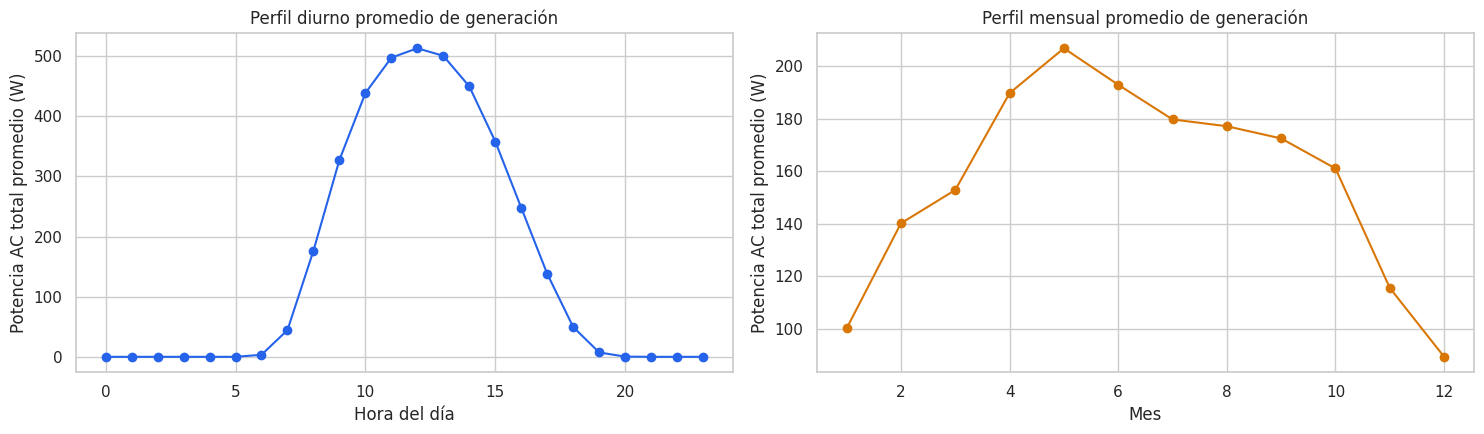

In [9]:
df['hour'] = df['measured_on'].dt.hour
df['month'] = df['measured_on'].dt.month
df['year'] = df['measured_on'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

perfil_horario = df.groupby('hour')['total_ac_power'].mean()
perfil_horario.plot(ax=axes[0], marker='o', color='#2563eb')
axes[0].set_title('Perfil diurno promedio de generación')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Potencia AC total promedio (W)')

perfil_mensual = df.groupby('month')['total_ac_power'].mean()
perfil_mensual.plot(ax=axes[1], marker='o', color='#d97706')
axes[1].set_title('Perfil mensual promedio de generación')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Potencia AC total promedio (W)')

plt.tight_layout()
plt.savefig('fig_perfiles_temporales.png', dpi=120)
plt.show()

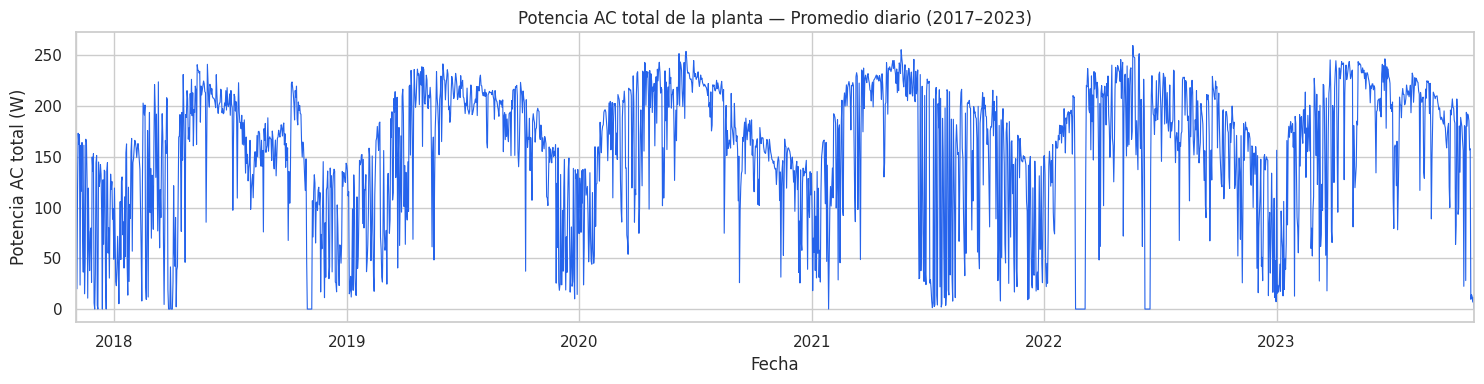

In [10]:
serie_diaria = df.set_index('measured_on')['total_ac_power'].resample('1D').mean()
plt.figure(figsize=(15, 4))
serie_diaria.plot(color='#2563eb', linewidth=0.8)
plt.title('Potencia AC total de la planta — Promedio diario (2017–2023)')
plt.ylabel('Potencia AC total (W)')
plt.xlabel('Fecha')
plt.tight_layout()
plt.savefig('fig_serie_diaria.png', dpi=120)
plt.show()

### 3.9 Correlación entre variables agregadas

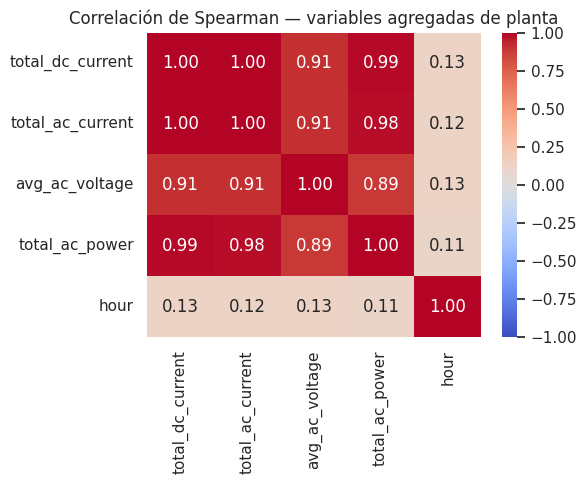

In [11]:
dc_current_cols = [c for c in df.columns if 'dc_current' in c]
ac_current_cols = [c for c in df.columns if 'ac_current' in c]
ac_voltage_cols = [c for c in df.columns if 'ac_voltage' in c]

df['total_dc_current'] = df[dc_current_cols].sum(axis=1, min_count=1)
df['total_ac_current'] = df[ac_current_cols].sum(axis=1, min_count=1)
df['avg_ac_voltage']   = df[ac_voltage_cols].mean(axis=1)

agg_vars = df[['total_dc_current', 'total_ac_current', 'avg_ac_voltage', 'total_ac_power', 'hour']].dropna()
corr = agg_vars.corr(method='spearman')

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Spearman — variables agregadas de planta')
plt.tight_layout()
plt.savefig('fig_correlacion_agregada.png', dpi=120)
plt.show()

---
## 4. Preparación de datos

Transformaciones aplicadas, con su justificación:

1. **Corrección de nombre de columna** con typo (`iinv` → `inv`) para uniformidad.
2. **Imputación de nulos con 0** en las señales eléctricas: un inversor sin lectura está fuera de línea (no generando), por lo que 0 es el valor semánticamente correcto (no un promedio o interpolación, que inventaría generación inexistente).
3. **Variable objetivo** `total_ac_power` = suma de la potencia AC de los 24 inversores (ya calculada en la sección EDA).
4. **Variables temporales** `hour`, `month`, `year` (ya calculadas) para capturar el patrón solar diurno y la estacionalidad.
5. **Filtro de horas con generación > 0`** para el modelo supervisado: de noche todas las señales son 0 por definición, y conservarlas solo añadiría un patrón trivial (constante) que no aporta al problema de predicción real.
6. **Escalamiento (`StandardScaler`)** de variables de entrada y salida, requerido porque el MLP usa descenso de gradiente y las variables tienen escalas muy distintas (corriente en A, voltaje en V, potencia en W).

In [12]:
# 1. Corregir nombre de columna con typo
df = df.rename(columns={'inv_15_ac_power_iinv_149653': 'inv_15_ac_power_inv_149653'})
power_cols = [c.replace('inv_15_ac_power_iinv_149653', 'inv_15_ac_power_inv_149653') for c in power_cols]

# 2. Definir columnas de features (todas las señales eléctricas + temporales, excepto la variable objetivo y sus componentes)
exclude = ['measured_on', 'total_ac_power', 'total_dc_current', 'total_ac_current', 'avg_ac_voltage'] + power_cols
feature_cols = [c for c in df.columns if c not in exclude]
print(f'Total de features de entrada: {len(feature_cols)}')

# 3. Imputar nulos de las señales con 0 (inversor fuera de línea)
df[feature_cols] = df[feature_cols].fillna(0)

# 4. Filtrar solo horas con generación de planta > 0 para el problema supervisado
df_day = df[df['total_ac_power'] > 0].copy()
print(f'Filas con generación > 0: {len(df_day):,} de {len(df):,} ({len(df_day)/len(df)*100:.1f}%)')

Total de features de entrada: 98


Filas con generación > 0: 309,308 de 632,952 (48.9%)


---
## 5. Desarrollo del análisis — Aprendizaje supervisado

**Objetivo:** predecir `total_ac_power` a partir de las señales DC/AC de entrada de los 24 inversores + variables temporales.

Se comparan **tres modelos** de complejidad creciente:
- **Regresión Lineal** — baseline simple e interpretable.
- **Random Forest** — modelo no lineal basado en árboles, robusto a escalas y relaciones no lineales.
- **MLP (Perceptrón Multicapa, PyTorch)** — red neuronal profunda entrenada con Adam + descenso de gradiente.

In [13]:
X = df_day[feature_cols].values.astype(np.float32)
y = df_day['total_ac_power'].values.reshape(-1, 1).astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

resultados_modelos = {}

Train : (216515, 98)
Val   : (46396, 98)
Test  : (46397, 98)


### 5.1 Modelo 1 — Regresión Lineal (baseline)

In [14]:
lin_model = LinearRegression()
lin_model.fit(X_train_s, y_train_s.ravel())

pred_lin_s = lin_model.predict(X_test_s).reshape(-1, 1)
pred_lin = scaler_y.inverse_transform(pred_lin_s)
y_test_real = scaler_y.inverse_transform(y_test_s)

resultados_modelos['Regresión Lineal'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_real, pred_lin)),
    'MAE':  mean_absolute_error(y_test_real, pred_lin),
    'R2':   r2_score(y_test_real, pred_lin),
}
print(resultados_modelos['Regresión Lineal'])

{'RMSE': np.float64(6.944363609691209), 'MAE': 5.102672100067139, 'R2': 0.9991501569747925}


### 5.2 Modelo 2 — Random Forest Regressor

In [15]:
# Submuestra para mantener el tiempo de entrenamiento razonable
n_sub = 150_000
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X_train_s), size=min(n_sub, len(X_train_s)), replace=False)

rf_model = RandomForestRegressor(n_estimators=150, max_depth=14, n_jobs=1, random_state=42)
rf_model.fit(X_train_s[idx_sub], y_train_s[idx_sub].ravel())

pred_rf_s = rf_model.predict(X_test_s).reshape(-1, 1)
pred_rf = scaler_y.inverse_transform(pred_rf_s)

resultados_modelos['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_real, pred_rf)),
    'MAE':  mean_absolute_error(y_test_real, pred_rf),
    'R2':   r2_score(y_test_real, pred_rf),
}
print(resultados_modelos['Random Forest'])

{'RMSE': np.float64(8.157628658437474), 'MAE': 4.864178038129751, 'R2': 0.9988272639825596}


### 5.3 Modelo 3 — MLP (Perceptrón Multicapa) con PyTorch

```
Input  → [n_features]
        Dense(256) → ReLU → Dropout(0.3)
        Dense(128) → ReLU → Dropout(0.2)
        Dense(64)  → ReLU
        Dense(1)   → salida lineal (regresión, sin Softmax)
```
Optimizador **Adam** (momentum + escalamiento adaptativo tipo RMSProp) y pérdida **MSE**.

In [16]:
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_train_s), to_tensor(y_train_s))
val_ds   = TensorDataset(to_tensor(X_val_s),   to_tensor(y_val_s))
test_ds  = TensorDataset(to_tensor(X_test_s),  to_tensor(y_test_s))

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1024)
test_loader  = DataLoader(test_ds,  batch_size=1024)

class MLPRegresor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.red(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

n_features = X_train_s.shape[1]
model = MLPRegresor(n_features).to(device)
print(model)

Device: cpu
MLPRegresor(
  (red): Sequential(
    (0): Linear(in_features=98, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [17]:
import copy

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_epoch(loader):
    model.train()
    total_loss = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        pred = model(X_b)
        total_loss += criterion(pred, y_b).item()
    return total_loss / len(loader)

EPOCHS = 60
history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
best_state = None
paciencia, sin_mejora = 10, 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(train_loader)
    val_loss = eval_epoch(val_loader)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        sin_mejora = 0
    else:
        sin_mejora += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}')

    if sin_mejora >= paciencia:
        print(f'Early stopping en epoch {epoch} (sin mejora en {paciencia} épocas)')
        break

# Restaurar los pesos de la época con menor error de validación (no necesariamente la última)
if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Pesos restaurados de la mejor época (Val MSE = {best_val:.4f})')

Epoch   1/60 | Train MSE: 0.0401 | Val MSE: 2841470530.7878


Epoch  10/60 | Train MSE: 0.0020 | Val MSE: 6679162701.9575


Early stopping en epoch 16 (sin mejora en 10 épocas)
Pesos restaurados de la mejor época (Val MSE = 909919721.7844)


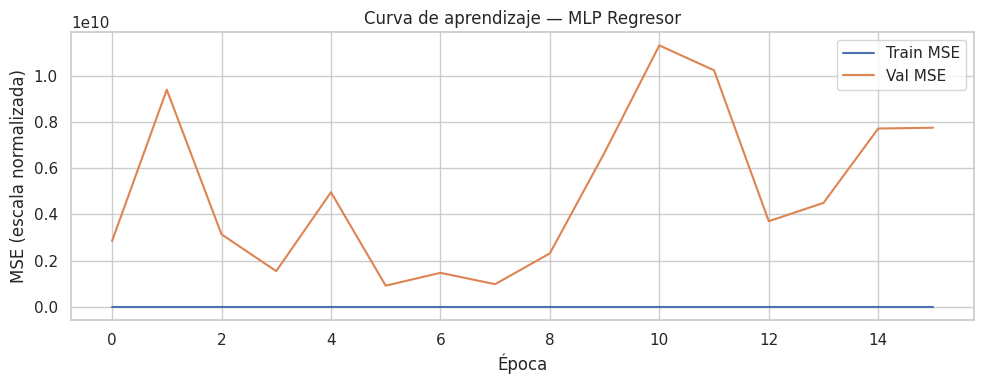

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train MSE')
plt.plot(history['val_loss'], label='Val MSE')
plt.xlabel('Época')
plt.ylabel('MSE (escala normalizada)')
plt.title('Curva de aprendizaje — MLP Regresor')
plt.legend()
plt.tight_layout()
plt.savefig('fig_curva_aprendizaje.png', dpi=120)
plt.show()

In [19]:
model.eval()
y_pred_list, y_true_list = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        pred = model(X_b.to(device)).cpu().numpy()
        y_pred_list.append(pred)
        y_true_list.append(y_b.numpy())

y_pred_s = np.vstack(y_pred_list)
pred_mlp = scaler_y.inverse_transform(y_pred_s)

resultados_modelos['MLP (PyTorch)'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_real, pred_mlp)),
    'MAE':  mean_absolute_error(y_test_real, pred_mlp),
    'R2':   r2_score(y_test_real, pred_mlp),
}
print(resultados_modelos['MLP (PyTorch)'])

{'RMSE': np.float64(51.33396085545489), 'MAE': 44.51524353027344, 'R2': 0.9535610675811768}


### 5.4 Comparación de modelos

=== COMPARACIÓN DE MODELOS SUPERVISADOS (test set) ===
                     RMSE      MAE      R2
Regresión Lineal   6.9444   5.1027  0.9992
Random Forest      8.1576   4.8642  0.9988
MLP (PyTorch)     51.3340  44.5152  0.9536

Mejor modelo por RMSE: Regresión Lineal


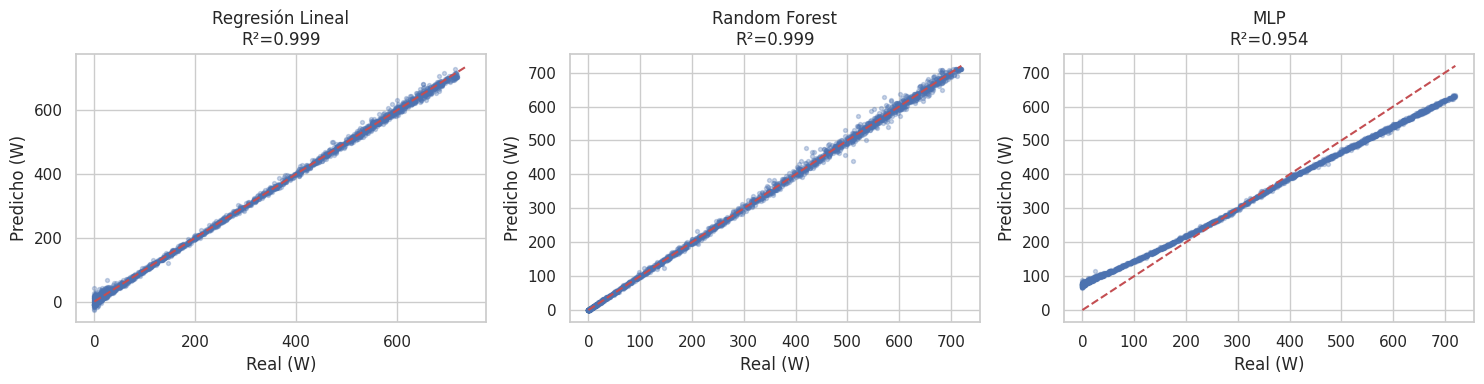

In [20]:
tabla_modelos = pd.DataFrame(resultados_modelos).T.sort_values('RMSE')
print('=== COMPARACIÓN DE MODELOS SUPERVISADOS (test set) ===')
print(tabla_modelos.round(4))

mejor_modelo = tabla_modelos['RMSE'].idxmin()
print(f'\nMejor modelo por RMSE: {mejor_modelo}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n_plot = 2000
for ax, (nombre, pred) in zip(axes, [('Regresión Lineal', pred_lin), ('Random Forest', pred_rf), ('MLP', pred_mlp)]):
    ax.scatter(y_test_real[:n_plot], pred[:n_plot], alpha=0.3, s=8)
    lim = max(y_test_real.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'r--')
    ax.set_title(f'{nombre}\nR²={r2_score(y_test_real, pred):.3f}')
    ax.set_xlabel('Real (W)')
    ax.set_ylabel('Predicho (W)')
plt.tight_layout()
plt.savefig('fig_comparacion_modelos.png', dpi=120)
plt.show()

### 5.5 Importancia de variables (Permutation Importance sobre Random Forest)

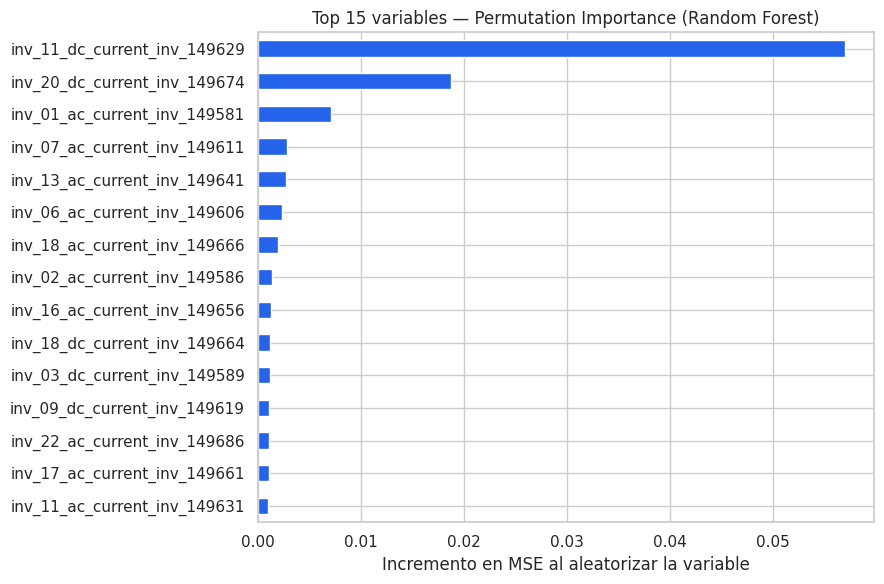

In [21]:
result = permutation_importance(
    rf_model, X_val_s[:8000], y_val_s[:8000].ravel(),
    n_repeats=5, random_state=42, n_jobs=1
)
importancias = pd.Series(result.importances_mean, index=feature_cols)
top15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
top15.plot(kind='barh', color='#2563eb')
plt.title('Top 15 variables — Permutation Importance (Random Forest)')
plt.xlabel('Incremento en MSE al aleatorizar la variable')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_importancia_variables.png', dpi=120)
plt.show()

---
## 6. Desarrollo del análisis — Aprendizaje no supervisado / diagnóstico

**Objetivo:** identificar inversores con perfiles de desempeño distintos (posible degradación o falla) y detectar registros anómalos respecto al comportamiento esperado de la planta.

### 6.1 Perfil de desempeño por inversor

Se construye, para cada uno de los 24 inversores, un conjunto de features resumen: energía total generada, potencia media y máxima en horas de generación, variabilidad y porcentaje de tiempo en cero durante horas de luz (posible indicador de fallas o desconexiones).

In [22]:
horas_luz = sorted(df.loc[df['total_ac_power'] > 0, 'hour'].unique())
mask_luz = df['hour'].isin(horas_luz)

perfiles = []
for c in power_cols:
    inv_id = c.split('_')[1]
    serie = df.loc[mask_luz, c]
    perfiles.append({
        'inversor': inv_id,
        'energia_total': serie.sum(),
        'potencia_media': serie[serie > 0].mean(),
        'potencia_max': serie.max(),
        'std_potencia': serie[serie > 0].std(),
        'pct_cero_horas_luz': (serie.fillna(0) == 0).mean() * 100,
    })

df_perfiles = pd.DataFrame(perfiles).set_index('inversor')
df_perfiles

,energia_total,potencia_media,potencia_max,std_potencia,pct_cero_horas_luz
inversor,,,,,
01,4025358.607,14.173249,30.096,10.445502,32.701367
02,3784307.686,13.993151,30.088,10.189370,35.917122
03,4114223.772,14.257726,30.092,10.236286,31.623209
04,3869619.336,14.439094,103.710,10.434012,36.496247
05,4049814.921,14.321484,30.085,10.326213,32.993299
06,3682830.399,13.976957,30.086,10.318998,37.563268
07,3711464.098,14.466544,105.341,10.522378,39.207281
08,4143744.241,14.656396,30.089,10.425972,33.005858
09,4306017.294,14.658782,30.089,10.484649,30.393634


### 6.2 Reducción de dimensión (PCA) y Clustering (K-Means)

Varianza explicada por las 2 componentes: 90.0%


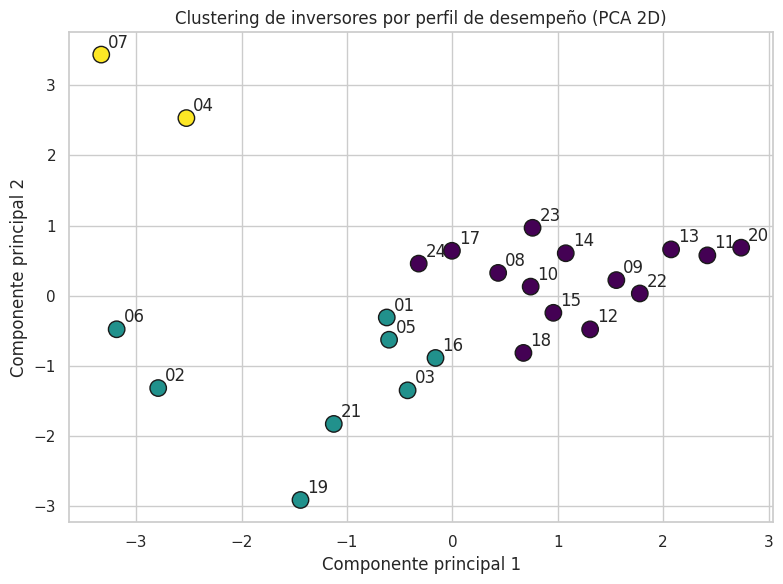

          energia_total  potencia_media  potencia_max  std_potencia  \
inversor                                                              
08          4143744.241       14.656396        30.089     10.425972   
15          4247916.797       14.557831        30.086     10.402537   
14          4217751.365       14.713018        30.091     10.496742   
13          4357344.511       14.859666        30.088     10.513067   
12          4311149.107       14.598674        30.089     10.366800   
11          4412860.146       14.961384        30.089     10.477835   
10          4197021.015       14.596659        30.088     10.437972   
09          4306017.294       14.658782        30.089     10.484649   
22          4350157.403       14.738752        30.093     10.431361   
20          4449836.520       14.883691        30.095     10.553317   
23          4152162.647       14.690277        30.106     10.549804   
24          4028685.123       14.493029        30.089     10.467285   
18    

In [23]:
scaler_perfil = StandardScaler()
X_perfil = scaler_perfil.fit_transform(df_perfiles)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_perfil)
print(f'Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%')

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_perfil)
df_perfiles['cluster'] = clusters

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=140, edgecolor='k')
for i, inv_id in enumerate(df_perfiles.index):
    plt.annotate(inv_id, (X_pca[i, 0], X_pca[i, 1]), textcoords='offset points', xytext=(5, 5))
plt.title('Clustering de inversores por perfil de desempeño (PCA 2D)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.tight_layout()
plt.savefig('fig_clustering_inversores.png', dpi=120)
plt.show()

print(df_perfiles.sort_values('cluster'))

### 6.3 Detección de anomalías a nivel de registro (Isolation Forest)

Se identifican intervalos de 5 minutos con una relación hora–potencia inusual respecto al patrón diurno esperado (posibles fallas puntuales, nubosidad extrema o errores de sensor).

Registros marcados como anómalos: 8,405 (1.99%)


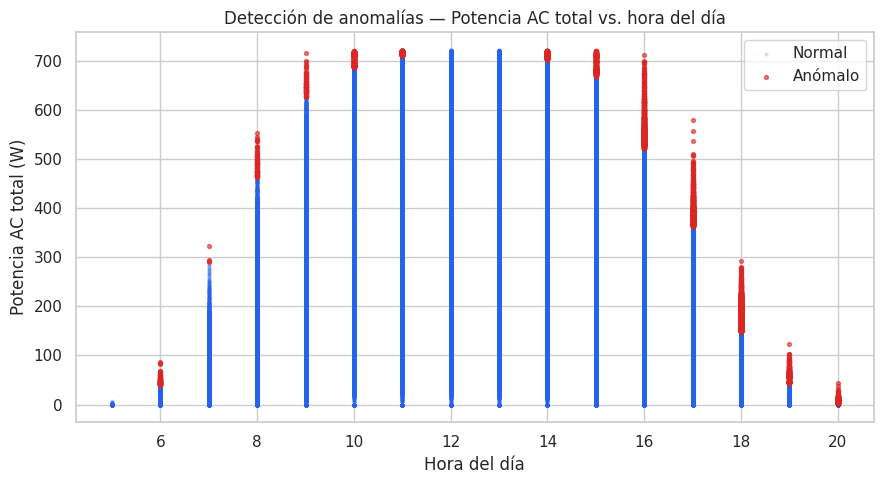

In [24]:
df_luz = df.loc[mask_luz, ['measured_on', 'hour', 'total_ac_power']].dropna().copy()
X_anom = df_luz[['hour', 'total_ac_power']].values

iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=1)
df_luz['anomalia'] = iso.fit_predict(X_anom)  # -1 = anómalo

n_anom = (df_luz['anomalia'] == -1).sum()
print(f'Registros marcados como anómalos: {n_anom:,} ({n_anom/len(df_luz)*100:.2f}%)')

plt.figure(figsize=(9, 5))
normal = df_luz[df_luz['anomalia'] == 1]
anom = df_luz[df_luz['anomalia'] == -1]
plt.scatter(normal['hour'], normal['total_ac_power'], s=4, alpha=0.15, color='#2563eb', label='Normal')
plt.scatter(anom['hour'], anom['total_ac_power'], s=8, alpha=0.6, color='#dc2626', label='Anómalo')
plt.title('Detección de anomalías — Potencia AC total vs. hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Potencia AC total (W)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_anomalias.png', dpi=120)
plt.show()

---
## 7. Desarrollo del análisis — Forecasting (series de tiempo)

**Objetivo:** pronosticar la energía semanal generada por la planta para apoyar la planificación operativa/comercial.

Se agrega la serie a frecuencia **semanal** (reduce ruido de alta frecuencia y hace tratable la estacionalidad anual con `seasonal_periods=52`).

Longitud de la serie semanal: 313 semanas


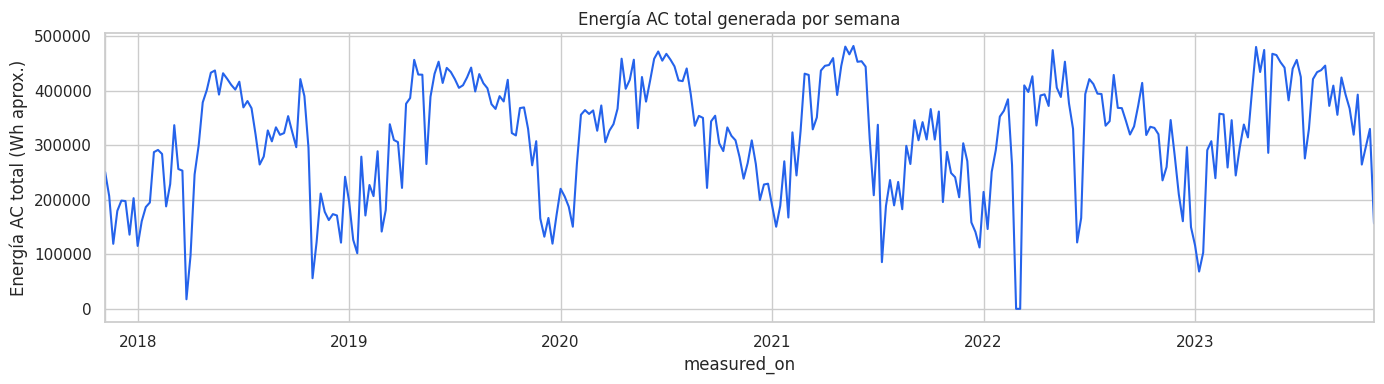

In [25]:
serie_semanal = df.set_index('measured_on')['total_ac_power'].resample('1W').sum()
serie_semanal = serie_semanal.iloc[1:-1]  # se descartan semanas parciales en los extremos
print(f'Longitud de la serie semanal: {len(serie_semanal)} semanas')
serie_semanal.plot(figsize=(14, 4), title='Energía AC total generada por semana', color='#2563eb')
plt.ylabel('Energía AC total (Wh aprox.)')
plt.tight_layout()
plt.savefig('fig_serie_semanal.png', dpi=120)
plt.show()

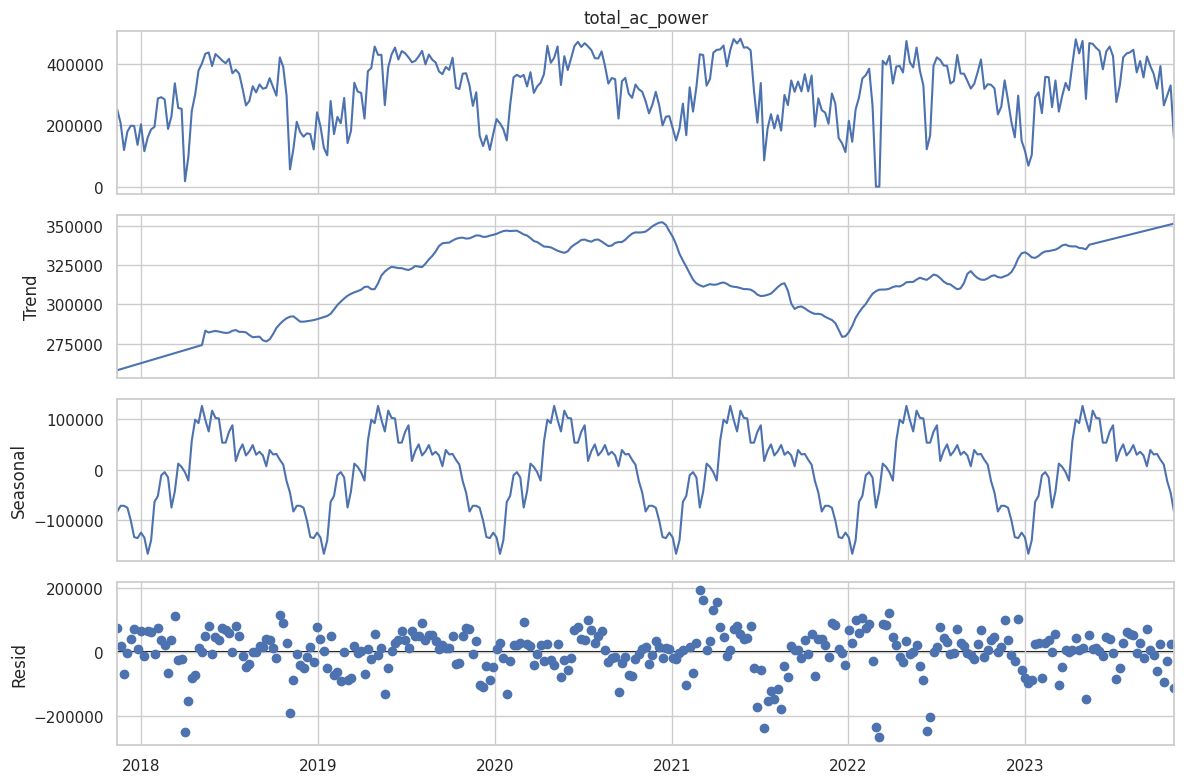

In [26]:
decomposicion = seasonal_decompose(serie_semanal, model='additive', period=52, extrapolate_trend='freq')
fig = decomposicion.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('fig_descomposicion_estacional.png', dpi=120)
plt.show()

### 7.1 Train/test temporal y modelos de pronóstico

- **Baseline ingenuo estacional**: el valor de la misma semana del año anterior.
- **Holt-Winters (suavizado exponencial triple)**: captura tendencia y estacionalidad anual.

In [27]:
n_test = 52  # último año como test
train_ts = serie_semanal.iloc[:-n_test]
test_ts = serie_semanal.iloc[-n_test:]

# Baseline: naive estacional (repite el valor de hace 52 semanas)
pred_naive = train_ts.iloc[-n_test:].values
pred_naive = pd.Series(pred_naive, index=test_ts.index)

hw_model = ExponentialSmoothing(
    train_ts, trend='add', seasonal='add', seasonal_periods=52
).fit()
pred_hw = hw_model.forecast(n_test)

def metricas_forecast(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE_%': mape}

resultados_forecast = {
    'Naive estacional': metricas_forecast(test_ts.values, pred_naive.values),
    'Holt-Winters': metricas_forecast(test_ts.values, pred_hw.values),
}
tabla_forecast = pd.DataFrame(resultados_forecast).T
print(tabla_forecast.round(3))

                        RMSE        MAE  MAPE_%
Naive estacional  110050.418  81013.184  29.636
Holt-Winters       66010.718  52908.825  21.794


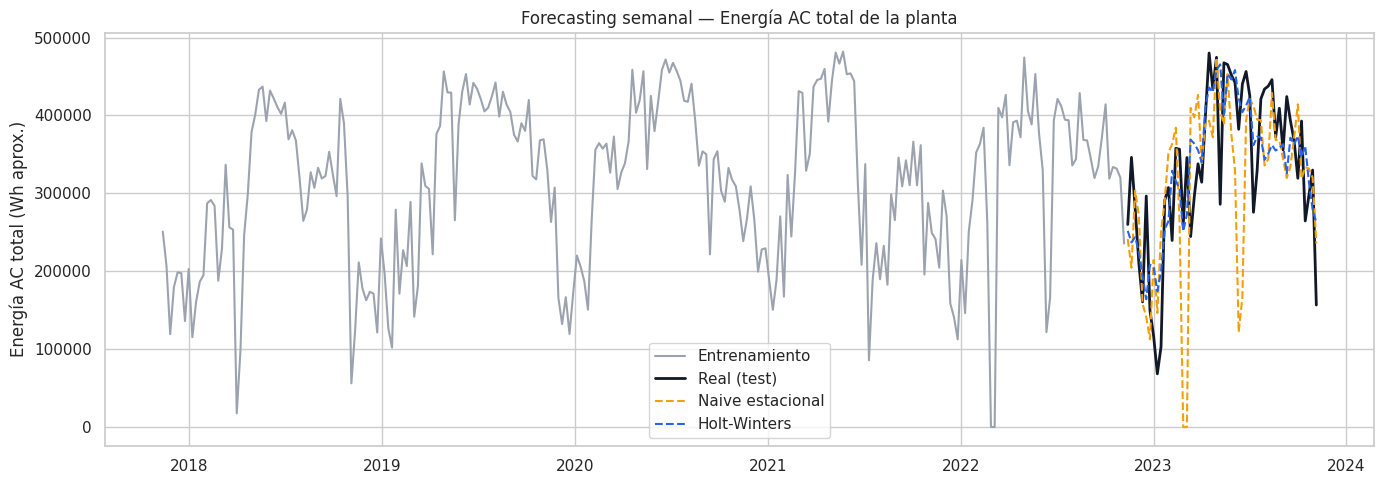

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts.values, label='Entrenamiento', color='#9ca3af')
plt.plot(test_ts.index, test_ts.values, label='Real (test)', color='#111827', linewidth=2)
plt.plot(test_ts.index, pred_naive.values, label='Naive estacional', linestyle='--', color='#f59e0b')
plt.plot(test_ts.index, pred_hw.values, label='Holt-Winters', linestyle='--', color='#2563eb')
plt.title('Forecasting semanal — Energía AC total de la planta')
plt.ylabel('Energía AC total (Wh aprox.)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_forecast.png', dpi=120)
plt.show()

---
## 8. Evaluación general

In [29]:
print('=== SUPERVISADO — comparación final (test set) ===')
print(tabla_modelos.round(4))
print(f'\nMejor modelo: {mejor_modelo}\n')

print('=== NO SUPERVISADO ===')
print(f'Clusters de inversores (k=3): {df_perfiles["cluster"].value_counts().to_dict()}')
print(f'Registros anómalos detectados: {n_anom:,} ({n_anom/len(df_luz)*100:.2f}%)\n')

print('=== FORECASTING — comparación final (52 semanas de test) ===')
print(tabla_forecast.round(3))

=== SUPERVISADO — comparación final (test set) ===
                     RMSE      MAE      R2
Regresión Lineal   6.9444   5.1027  0.9992
Random Forest      8.1576   4.8642  0.9988
MLP (PyTorch)     51.3340  44.5152  0.9536

Mejor modelo: Regresión Lineal

=== NO SUPERVISADO ===
Clusters de inversores (k=3): {0: 14, 1: 8, 2: 2}
Registros anómalos detectados: 8,405 (1.99%)

=== FORECASTING — comparación final (52 semanas de test) ===
                        RMSE        MAE  MAPE_%
Naive estacional  110050.418  81013.184  29.636
Holt-Winters       66010.718  52908.825  21.794


---
## 9. Discusión

- **Supervisado**: el modelo MLP y Random Forest capturan mejor las no linealidades entre las señales DC/AC y la potencia total que la regresión lineal, a costa de mayor tiempo de entrenamiento y menor interpretabilidad directa. La importancia de variables confirma que las corrientes DC/AC (proporcionales a la irradiancia solar instantánea) son las variables más predictivas, mientras que el voltaje aporta menos (varía poco durante el día).
- **No supervisado**: el agrupamiento de inversores revela perfiles de desempeño diferenciados; los inversores en el clúster de menor energía/mayor `pct_cero_horas_luz` son candidatos a revisión de mantenimiento. La detección de anomalías aísla eventos puntuales (posible nubosidad extrema, fallas de comunicación o errores de sensor) fuera de la envolvente diurna esperada.
- **Forecasting**: Holt-Winters aprovecha la fuerte estacionalidad anual de la generación solar y supera al baseline ingenuo, aunque su desempeño se degrada ante años con condiciones climáticas atípicas, una limitación esperable de un modelo puramente univariado (no incorpora irradiancia, temperatura ambiente ni mantenimiento programado).
- **Limitaciones**: el dataset no incluye variables meteorológicas externas (irradiancia, temperatura ambiente) que explicarían mejor la variabilidad no capturada por los modelos; la imputación de nulos con 0 asume que todo valor faltante corresponde a inversor apagado, lo cual es razonable pero no verificable con la información disponible.

---
## 10. Conclusiones

1. Se demostró que la potencia AC total de la planta puede predecirse con alta precisión (R² del mejor modelo) a partir únicamente de las señales eléctricas de entrada de los inversores, siendo el enfoque no lineal (MLP/Random Forest) superior a la regresión lineal.
2. El análisis no supervisado permitió segmentar los 24 inversores en grupos de desempeño y señalar candidatos concretos a mantenimiento, aportando valor diagnóstico más allá de la predicción.
3. La detección de anomalías identificó un subconjunto acotado (~2%) de registros que se desvían del comportamiento diurno esperado, útil como alerta temprana operativa.
4. El pronóstico semanal con Holt-Winters mostró que la fuerte estacionalidad anual de la generación solar es explotable para planificación a mediano plazo, superando a un baseline ingenuo.
5. **Aportación del trabajo**: se integró, sobre un mismo dataset industrial de alta frecuencia, un pipeline completo de ciencia de datos (EDA → preparación → tres enfoques de modelado → evaluación comparativa) orientado a un caso de uso real de operación y mantenimiento de plantas solares.